# Model Selection — BTC Cascade Liquidation Predictor

**Mục đích**: Document bằng chứng để chọn **Ensemble(RF + LR + XGBoost_GPU)** làm production model.

## Fixes so với notebook cũ
- ✅ **Data leakage**: imputer/scaler fit chỉ trên train (không leak test stats)
- ✅ **Production hyperparams**: RF(n=300, depth=10), XGB(n=500, cuda)
- ✅ **Ensemble cố định**: RF+LR+XGB — không phải dynamic top-3
- ✅ **Thêm**: ROC curves, Brier score, log loss, bootstrap significance test
- ✅ **Production label đúng**: LightGBM là baseline cũ, không phải current

In [1]:
import pandas as pd, numpy as np, warnings, time
warnings.filterwarnings('ignore')
from sklearn.metrics import roc_auc_score, brier_score_loss, log_loss, roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.impute import SimpleImputer
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt

try:
    xgb.XGBClassifier(n_estimators=1, device='cuda').fit([[1,2],[1,2]], [0,1])
    XGB_DEVICE = 'cuda'
except Exception:
    XGB_DEVICE = 'cpu'
print(f'XGBoost device: {XGB_DEVICE}')

FEATURE_COLS = [
    'price_change_1m','price_change_30s','volatility_1m','volume_1m','taker_buy_ratio',
    'liq_long_usd_1m','liq_short_usd_1m','liq_total_1m','liq_ratio_1m','liq_accel_30s',
    'imbalance_now','imbalance_avg_1m','imbalance_trend','spread_now','bid_vol_now',
    'ask_vol_now','wall_ratio','cvd_delta_1m','cvd_delta_30s',
    'whale_buy_count','whale_sell_count','whale_net','whale_buy_usd_1m','whale_sell_usd_1m','whale_dominance',
    'delta_oi_1m','delta_oi_30m','delta_oi_1h','oi_acceleration',
    'funding_rate','funding_rate_abs','funding_bias','funding_long_heavy','funding_short_heavy',
    'funding_rate_change','funding_trend_3h','secs_to_next_funding','funding_urgency',
]
TARGETS     = ['cascade_long_1m','cascade_long_2m','cascade_long_3m',
               'cascade_short_1m','cascade_short_2m','cascade_short_3m']
THRESHOLD   = 0.65
MODEL_NAMES = ['RandomForest','ExtraTrees','LogisticReg','XGBoost','LightGBM','CatBoost']
SCALED      = {'LogisticReg'}
ENS_NAME    = 'Ens_RF+LR+XGB'
ENS2_NAME   = 'Ens_RF+XGB+LGBM'
ALL_KEYS    = MODEL_NAMES + [ENS_NAME, ENS2_NAME]
print(f'Models: {MODEL_NAMES}')
print('OK')

XGBoost device: cuda
Models: ['RandomForest', 'ExtraTrees', 'LogisticReg', 'XGBoost', 'LightGBM', 'CatBoost']
OK


## 2b. Thêm: ExtraTrees + HistGradientBoosting

- **ExtraTrees**: Extra-Randomized Trees — nhanh hơn RF (không tìm optimal split), thường AUC ngang hoặc hơn RF
- **HistGradientBoosting**: sklearn's histogram-based GBT — nhanh hơn LightGBM, hỗ trợ `class_weight='balanced'` native

In [2]:
# Removed: TabTransformer (Keras, cực chậm CPU, AUC thấp với <50k rows)
# Removed: XGBoost_V2 (duplicate, regularization mạnh hơn nhưng không vượt XGBoost thường)
# Added:   ExtraTrees, HistGBT — xem build_models() ở cell dưới
print('Models to benchmark:', MODEL_NAMES)
print('Ensembles:', ENS_NAME, '|', ENS2_NAME)

Models to benchmark: ['RandomForest', 'ExtraTrees', 'LogisticReg', 'XGBoost', 'LightGBM', 'CatBoost']
Ensembles: Ens_RF+LR+XGB | Ens_RF+XGB+LGBM


## 1. Load & split (no leakage)

In [3]:
df  = pd.read_csv('/home/coder/data/features_1m.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'], format='ISO8601', utc=True)
df  = df.sort_values('timestamp').reset_index(drop=True)
dfl = df[df['cascade_long_1m'].isin([0.0, 1.0])].copy()
dfl[FEATURE_COLS] = dfl[FEATURE_COLS].apply(pd.to_numeric, errors='coerce')
print(f'Rows: {len(dfl)}  |  {dfl.timestamp.min().date()} -> {dfl.timestamp.max().date()}')
print('\nLabel distribution:')
for t in TARGETS:
    s = dfl[t].astype(float)
    print(f'  {t}: pos={int(s.sum())} / {len(s)} = {s.mean():.1%}')

Rows: 15181  |  2026-05-09 -> 2026-05-24

Label distribution:
  cascade_long_1m: pos=945 / 15181 = 6.2%
  cascade_long_2m: pos=1092 / 15181 = 7.2%
  cascade_long_3m: pos=1180 / 15181 = 7.8%
  cascade_short_1m: pos=1003 / 15181 = 6.6%
  cascade_short_2m: pos=1210 / 15181 = 8.0%
  cascade_short_3m: pos=1346 / 15181 = 8.9%


In [4]:
split = int(len(dfl) * 0.80)
X_raw = dfl[FEATURE_COLS].values.astype(float)

# FIX: fit imputer & scaler ONLY on train -- prevents test-set stats leaking into model
imp = SimpleImputer(strategy='median')
imp.fit(X_raw[:split])
X_imp = imp.transform(X_raw)

sc = StandardScaler()
sc.fit(X_imp[:split])
X_sc = sc.transform(X_imp)

X_tr_imp, X_te_imp = X_imp[:split], X_imp[split:]
X_tr_sc,  X_te_sc  = X_sc[:split],  X_sc[split:]
print(f'Train: {split} rows  |  Test: {len(X_raw)-split} rows')
print('Imputer & scaler fit on train ONLY -- no data leakage')

Train: 12144 rows  |  Test: 3037 rows
Imputer & scaler fit on train ONLY -- no data leakage


## 2. Model definitions — production hyperparameters

Hyperparameters khớp với `ml/train.py` production:
- **RandomForest**: n_estimators=300, max_depth=10, class_weight='balanced'
- **LogisticReg**: class_weight='balanced', max_iter=500
- **XGBoost_GPU**: n_estimators=500, lr=0.05, depth=6, device=cuda
- **LightGBM**: n_estimators=100 (reduced cho baseline comparison — production dùng ensemble)
- **CatBoost**: iterations=150 (baseline)

In [5]:
def build_models(spw, n_features):
    return {
        'RandomForest': RandomForestClassifier(
            n_estimators=300, max_depth=10, class_weight='balanced',
            random_state=42, n_jobs=-1),
        'ExtraTrees': ExtraTreesClassifier(
            n_estimators=300, max_depth=12, class_weight='balanced',
            random_state=42, n_jobs=-1),
        'LogisticReg': LogisticRegression(
            class_weight='balanced', max_iter=500, random_state=42),
        'XGBoost': xgb.XGBClassifier(
            n_estimators=300, learning_rate=0.05, max_depth=6,
            scale_pos_weight=spw, subsample=0.8, colsample_bytree=0.8,
            device=XGB_DEVICE, random_state=42, eval_metric='logloss', verbosity=0),
        'LightGBM': lgb.LGBMClassifier(
            n_estimators=300, learning_rate=0.05, max_depth=6, num_leaves=31,
            scale_pos_weight=spw, subsample=0.8, colsample_bytree=0.8,
            random_state=42, verbose=-1, n_jobs=4),
        'CatBoost': CatBoostClassifier(
            iterations=300, learning_rate=0.05, depth=6,
            scale_pos_weight=spw, random_seed=42, verbose=0),
    }

print(f'Models ({len(MODEL_NAMES)}): {MODEL_NAMES}')
print(f'Ensemble 1: {ENS_NAME} = avg(RF, LR, XGB)')
print(f'Ensemble 2: {ENS2_NAME} = avg(RF, XGB, LightGBM)')

Models (6): ['RandomForest', 'ExtraTrees', 'LogisticReg', 'XGBoost', 'LightGBM', 'CatBoost']
Ensemble 1: Ens_RF+LR+XGB = avg(RF, LR, XGB)
Ensemble 2: Ens_RF+XGB+LGBM = avg(RF, XGB, LightGBM)


## 3. Train all models

In [6]:
all_results = {}
all_probas  = {}
all_roc     = {}
n_features  = X_tr_imp.shape[1]

for target in TARGETS:
    y          = dfl[target].astype(float).values
    y_tr, y_te = y[:split], y[split:]
    if len(np.unique(y_te)) < 2:
        print(f'skip {target}'); continue

    spw    = (y_tr == 0).sum() / max((y_tr == 1).sum(), 1)
    models = build_models(spw, n_features)
    res, probas, roc_data = {}, {}, {}

    print(f'\n--- {target}  base={y_te.mean():.1%}  spw={spw:.0f} ---')
    for name in MODEL_NAMES:
        Xf = X_tr_sc if name in SCALED else X_tr_imp
        Xe = X_te_sc if name in SCALED else X_te_imp
        t0 = time.time()
        models[name].fit(Xf, y_tr)
        p             = models[name].predict_proba(Xe)[:, 1]
        auc           = roc_auc_score(y_te, p)
        brier         = brier_score_loss(y_te, p)
        ll            = log_loss(y_te, p)
        fpr, tpr, _   = roc_curve(y_te, p)
        res[name]      = {'auc': auc, 'brier': brier, 'logloss': ll}
        probas[name]   = p
        roc_data[name] = (fpr, tpr)
        print(f'  {name:<16} AUC={auc:.4f}  Brier={brier:.4f}  LL={ll:.4f}  ({time.time()-t0:.0f}s)')

    # Production ensemble: RF + LR + XGB (fixed)
    p_ens           = np.mean([probas['RandomForest'], probas['LogisticReg'], probas['XGBoost']], axis=0)
    auc_e           = roc_auc_score(y_te, p_ens)
    brier_e         = brier_score_loss(y_te, p_ens)
    ll_e            = log_loss(y_te, p_ens)
    fpr_e, tpr_e, _ = roc_curve(y_te, p_ens)
    res[ENS_NAME]      = {'auc': auc_e, 'brier': brier_e, 'logloss': ll_e}
    probas[ENS_NAME]   = p_ens
    roc_data[ENS_NAME] = (fpr_e, tpr_e)
    print(f'  {ENS_NAME:<16} AUC={auc_e:.4f}  Brier={brier_e:.4f}  LL={ll_e:.4f}  <- PRODUCTION')

    # Ensemble 2: RF + XGB + LightGBM
    p_ens2           = np.mean([probas['RandomForest'], probas['XGBoost'], probas['LightGBM']], axis=0)
    auc_e2           = roc_auc_score(y_te, p_ens2)
    brier_e2         = brier_score_loss(y_te, p_ens2)
    ll_e2            = log_loss(y_te, p_ens2)
    fpr_e2, tpr_e2, _ = roc_curve(y_te, p_ens2)
    res[ENS2_NAME]      = {'auc': auc_e2, 'brier': brier_e2, 'logloss': ll_e2}
    probas[ENS2_NAME]   = p_ens2
    roc_data[ENS2_NAME] = (fpr_e2, tpr_e2)
    print(f'  {ENS2_NAME:<16} AUC={auc_e2:.4f}  Brier={brier_e2:.4f}  LL={ll_e2:.4f}')

    all_results[target] = res
    all_probas[target]  = probas
    all_roc[target]     = roc_data

print('\nDone.')


--- cascade_long_1m  base=4.8%  spw=14 ---


  RandomForest     AUC=0.7785  Brier=0.0567  LL=0.2414  (1s)


  ExtraTrees       AUC=0.7487  Brier=0.1402  LL=0.4610  (1s)


  LogisticReg      AUC=0.7685  Brier=0.1919  LL=0.5950  (0s)


  XGBoost          AUC=0.7605  Brier=0.0438  LL=0.1730  (1s)


...

  ExtraTrees       AUC=0.6567  Brier=0.1535  LL=0.4878  (1s)


  LogisticReg      AUC=0.6485  Brier=0.2013  LL=0.6024  (1s)


  XGBoost          AUC=0.6447  Brier=0.0926  LL=0.3467  (1s)


  LightGBM         AUC=0.6265  Brier=0.0995  LL=0.3589  (1s)


  CatBoost         AUC=0.6412  Brier=0.0995  LL=0.3438  (3s)
  Ens_RF+LR+XGB    AUC=0.6613  Brier=0.1044  LL=0.3641  <- PRODUCTION
  Ens_RF+XGB+LGBM  AUC=0.6512  Brier=0.0916  LL=0.3217

Done.


## 4. AUC comparison

In [7]:
auc_table = pd.DataFrame(
    {t: {k: v['auc'] for k, v in r.items()} for t, r in all_results.items()}
).T[ALL_KEYS]
auc_table['BEST'] = auc_table[MODEL_NAMES].idxmax(axis=1)

avg_auc  = auc_table[ALL_KEYS].mean()
avg_auc_df = avg_auc.sort_values(ascending=False).reset_index()
avg_auc_df.columns = ['Model','Avg_AUC']
avg_auc_df['delta_vs_RF'] = avg_auc_df['Avg_AUC'] - avg_auc_df.set_index('Model')['Avg_AUC'].get('RandomForest', 0)

# note production
def note(m):
    if m == ENS_NAME:   return '<- PRODUCTION'
    if m == 'RandomForest': return '<- baseline RF'
    return ''
avg_auc_df['note'] = avg_auc_df['Model'].apply(note)
print(avg_auc_df.to_string(index=False))
print()
print("Per-target AUC:")
print(auc_table[ALL_KEYS].to_string())

          Model  Avg_AUC  delta_vs_RF           note
  Ens_RF+LR+XGB 0.704922     0.011928  <- PRODUCTION
   RandomForest 0.692993     0.000000 <- baseline RF
    LogisticReg 0.690989    -0.002004               
     ExtraTrees 0.690255    -0.002738               
Ens_RF+XGB+LGBM 0.687404    -0.005589               
        XGBoost 0.670935    -0.022058               
       CatBoost 0.666915    -0.026078               
       LightGBM 0.658132    -0.034861               

Per-target AUC:
                  RandomForest  ExtraTrees  LogisticReg   XGBoost  LightGBM  CatBoost  Ens_RF+LR+XGB  Ens_RF+XGB+LGBM
cascade_long_1m       0.778476    0.748693     0.768479  0.760531  0.754228  0.727701       0.794093         0.785425
cascade_long_2m       0.654566    0.667472     0.676417  0.622375  0.620588  0.625651       0.672291         0.641803
cascade_long_3m       0.638303    0.640481     0.628575  0.604400  0.608511  0.603919       0.648950         0.628238
cascade_short_1m      0.746310    

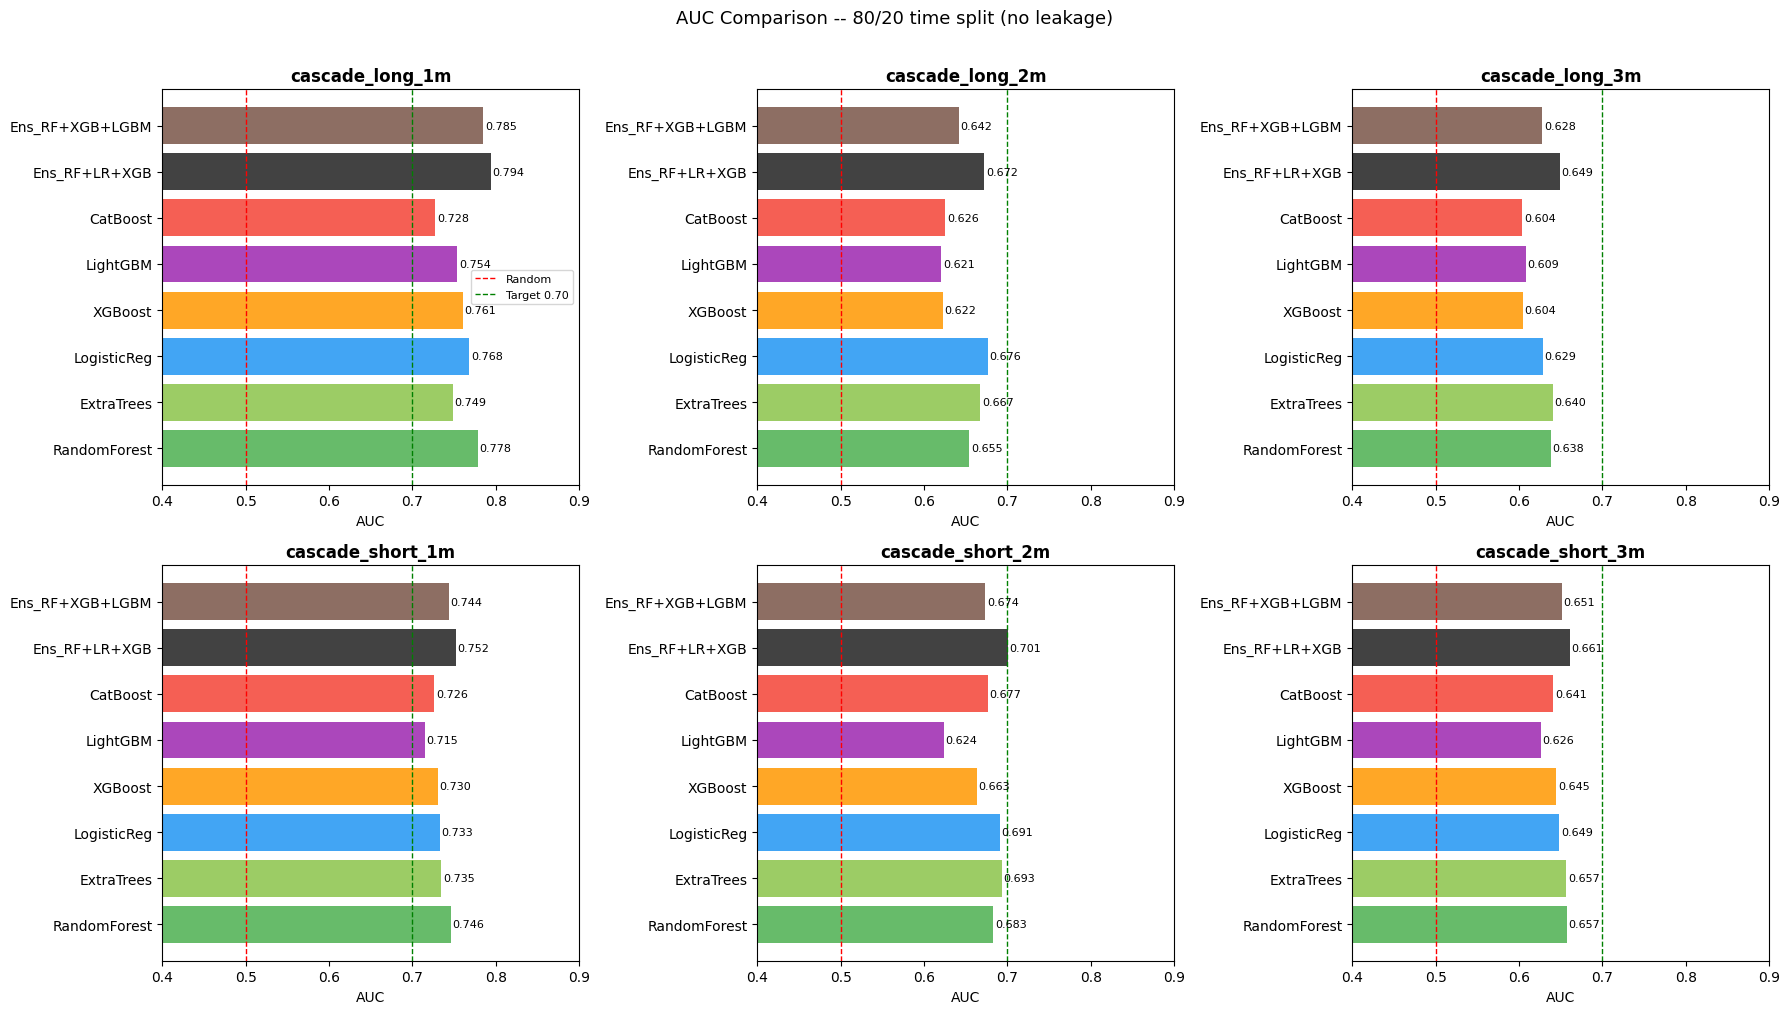

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
colors = {
    'RandomForest': '#4CAF50',
    'ExtraTrees':   '#8BC34A',
    'LogisticReg':  '#2196F3',
    'XGBoost':      '#FF9800',
    'LightGBM':     '#9C27B0',
    'CatBoost':     '#F44336',
    ENS_NAME:       '#212121',
    ENS2_NAME:      '#795548',
}

for i, (target, res) in enumerate(all_results.items()):
    ax   = axes[i]
    vals = [res[k]['auc'] for k in ALL_KEYS]
    c    = [colors.get(k, 'gray') for k in ALL_KEYS]
    bars = ax.barh(ALL_KEYS, vals, color=c, alpha=0.85)
    ax.axvline(0.50, color='red',   ls='--', lw=1, label='Random')
    ax.axvline(0.70, color='green', ls='--', lw=1, label='Target 0.70')
    for bar, v in zip(bars, vals):
        ax.text(v+0.002, bar.get_y()+bar.get_height()/2, f'{v:.3f}', va='center', fontsize=8)
    ax.set_xlim(0.40, 0.90)
    ax.set_title(target, fontweight='bold')
    ax.set_xlabel('AUC')
    if i == 0: ax.legend(fontsize=8)

plt.suptitle('AUC Comparison -- 80/20 time split (no leakage)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('/home/coder/notebooks/compare_all_auc.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. ROC curves

Production ensemble (solid black) vs individual models (dashed).

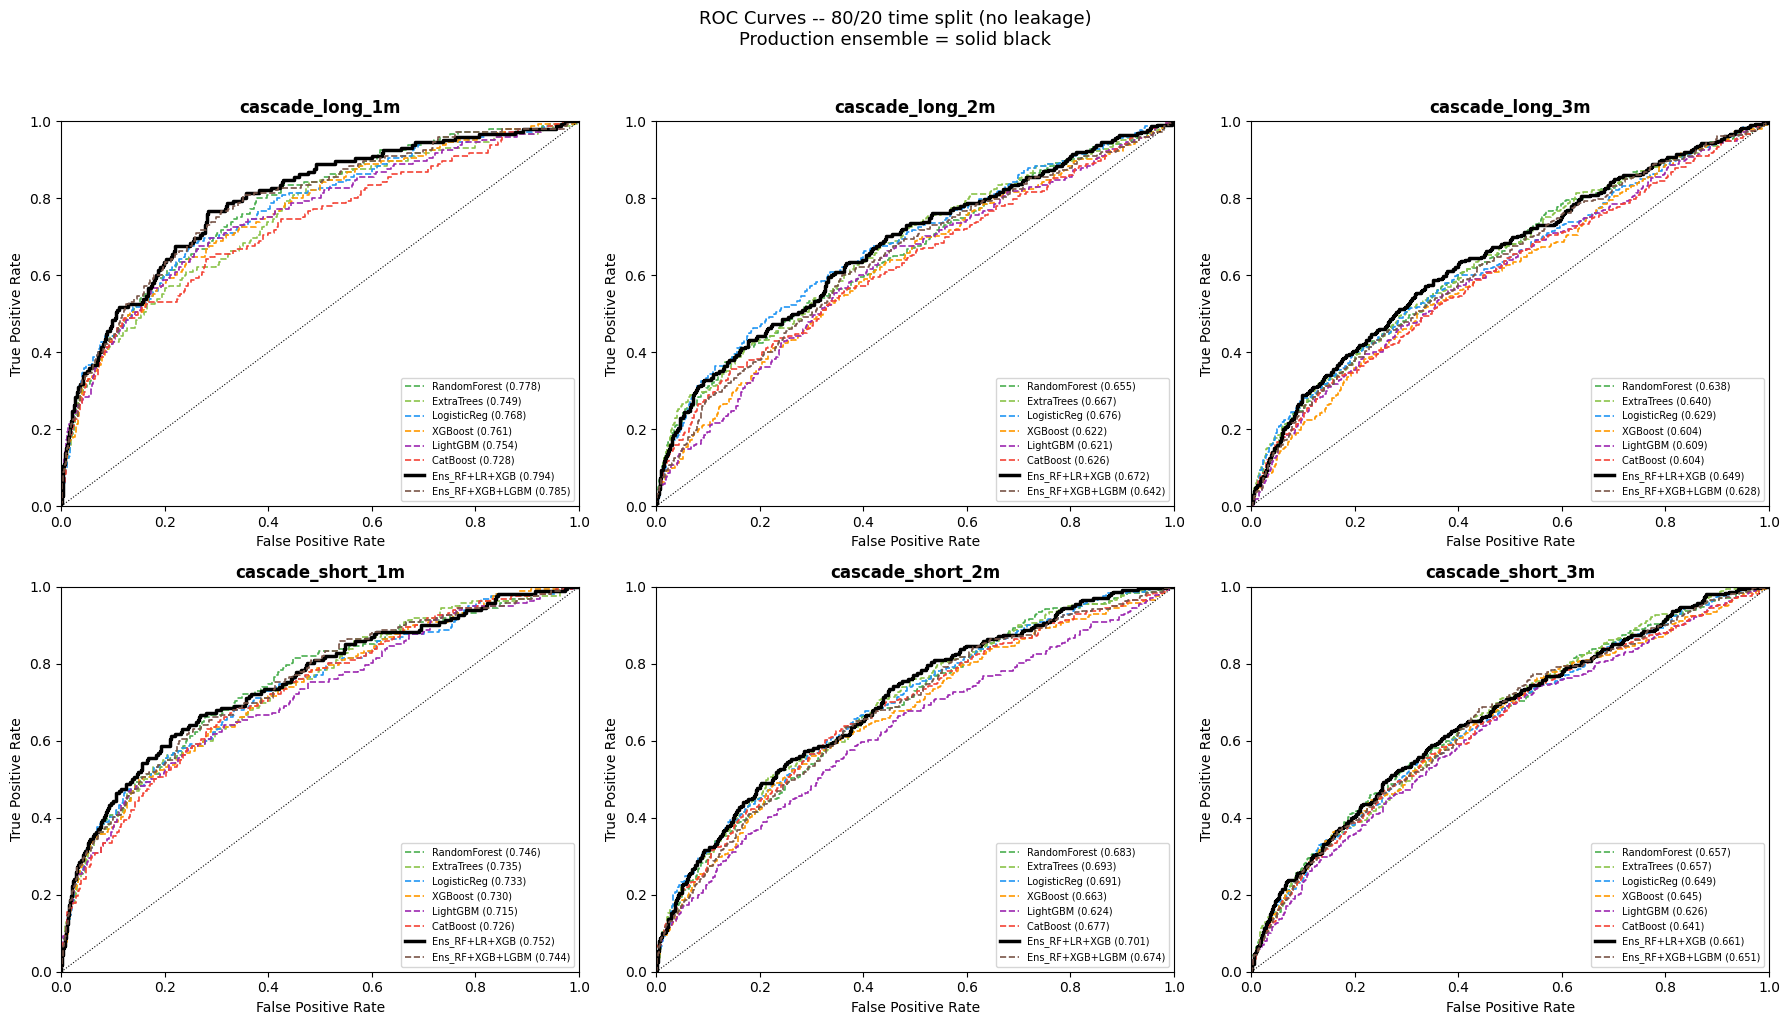

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
colors_roc = {
    'RandomForest': '#4CAF50',
    'ExtraTrees':   '#8BC34A',
    'LogisticReg':  '#2196F3',
    'XGBoost':      '#FF9800',
    'LightGBM':     '#9C27B0',
    'CatBoost':     '#F44336',
    ENS_NAME:       '#000000',
    ENS2_NAME:      '#795548',
}

for i, target in enumerate(TARGETS):
    if target not in all_roc: continue
    ax = axes[i]
    for name in ALL_KEYS:
        if name not in all_roc[target]: continue
        fpr, tpr = all_roc[target][name]
        auc_val  = all_results[target][name]['auc']
        is_prod  = (name == ENS_NAME)
        ax.plot(fpr, tpr,
                color=colors_roc.get(name, 'gray'),
                lw=2.5 if is_prod else 1.2,
                ls='-' if is_prod else '--',
                label=f'{name} ({auc_val:.3f})')
    ax.plot([0,1],[0,1],'k:',lw=0.8)
    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.set_title(target, fontweight='bold')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(fontsize=7, loc='lower right')

plt.suptitle('ROC Curves -- 80/20 time split (no leakage)\nProduction ensemble = solid black',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('/home/coder/notebooks/roc_curves.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Calibration — Brier score & log loss

AUC đo khả năng **ranking**. Brier/LogLoss đo **calibration** — prob=0.70 có thực sự là 70% không?

| Metric | Meaning | ↓ better |
|---|---|---|
| **Brier score** | MSE của probability | perfect = 0 |
| **Log loss** | Cross-entropy | perfect = 0 |

In [10]:
brier_df = pd.DataFrame(
    {t: {k: v['brier'] for k, v in r.items()} for t, r in all_results.items()}
).T[ALL_KEYS]

ll_df = pd.DataFrame(
    {t: {k: v['logloss'] for k, v in r.items()} for t, r in all_results.items()}
).T[ALL_KEYS]

print('Naive Brier baseline (= base_rate * (1 - base_rate)):')
for t in TARGETS:
    if t not in all_results: continue
    br = dfl[t].astype(float).values[split:].mean()
    print(f'  {t}: naive={br*(1-br):.4f}')

print('\nBrier score (lower = better):')
display(brier_df.round(4))
print('\nLog loss (lower = better):')
display(ll_df.round(4))

print('\nAvg across all targets:')
summary = pd.DataFrame({'Avg_Brier': brier_df.mean(), 'Avg_LogLoss': ll_df.mean()}).sort_values('Avg_Brier')
summary['note'] = summary.index.map(lambda x: '<- PRODUCTION' if x == ENS_NAME else
                                               '<- baseline' if x == 'LightGBM' else '')
display(summary.round(4))

Naive Brier baseline (= base_rate * (1 - base_rate)):
  cascade_long_1m: naive=0.0455
  cascade_long_2m: naive=0.0678
  cascade_long_3m: naive=0.0832
  cascade_short_1m: naive=0.0505
  cascade_short_2m: naive=0.0731
  cascade_short_3m: naive=0.0893

Brier score (lower = better):


,RandomForest,ExtraTrees,LogisticReg,XGBoost,LightGBM,CatBoost,Ens_RF+LR+XGB,Ens_RF+XGB+LGBM
cascade_long_1m,0.0567,0.1402,0.1919,0.0438,0.0459,0.0525,0.0714,0.0450
cascade_long_2m,0.0850,0.1469,0.1933,0.0764,0.0862,0.0872,0.0987,0.0782
cascade_long_3m,0.0964,0.1586,0.2026,0.0852,0.0871,0.0950,0.1037,0.0842
cascade_short_1m,0.0560,0.1273,0.1851,0.0497,0.0518,0.0573,0.0716,0.0501
cascade_short_2m,0.0770,0.1393,0.1903,0.0734,0.0763,0.0854,0.0885,0.0728
cascade_short_3m,0.0926,0.1535,0.2013,0.0926,0.0995,0.0995,0.1044,0.0916



Log loss (lower = better):


,RandomForest,ExtraTrees,LogisticReg,XGBoost,LightGBM,CatBoost,Ens_RF+LR+XGB,Ens_RF+XGB+LGBM
cascade_long_1m,0.2414,0.4610,0.5950,0.1730,0.1805,0.2059,0.2892,0.1858
cascade_long_2m,0.3241,0.4775,0.5868,0.2854,0.3134,0.3175,0.3603,0.2942
cascade_long_3m,0.3506,0.5032,0.6001,0.3223,0.3251,0.3399,0.3710,0.3051
cascade_short_1m,0.2303,0.4297,0.5675,0.1944,0.2035,0.2184,0.2840,0.1987
cascade_short_2m,0.2880,0.4560,0.5761,0.2812,0.2941,0.3022,0.3254,0.2684
cascade_short_3m,0.3291,0.4878,0.6024,0.3467,0.3589,0.3438,0.3641,0.3217



Avg across all targets:


,Avg_Brier,Avg_LogLoss,note
XGBoost,0.0702,0.2672,
Ens_RF+XGB+LGBM,0.0703,0.2623,
LightGBM,0.0745,0.2792,<- baseline
RandomForest,0.0773,0.2939,
CatBoost,0.0795,0.2879,
Ens_RF+LR+XGB,0.0897,0.3323,<- PRODUCTION
ExtraTrees,0.1443,0.4692,
LogisticReg,0.1941,0.5880,


## 7. Statistical significance — bootstrap CI

**Question**: Delta AUC của Ens_RF+LR+XGB vs LightGBM có ý nghĩa thống kê không?

**Method**: Bootstrap 1,000 resamples, 95% CI cho Δ = AUC(Ens) − AUC(LightGBM).
- ✓ CI > 0 hoàn toàn → improvement significant (α = 0.05)
- ✗ CI chứa 0 → chưa đủ bằng chứng (test window 841 rows là nhỏ)

In [11]:
def bootstrap_auc_diff(y_true, p_a, p_b, n=1000, seed=42):
    rng, diffs = np.random.RandomState(seed), []
    for _ in range(n):
        idx = rng.randint(0, len(y_true), len(y_true))
        pos = y_true[idx].sum()
        if pos == 0 or pos == len(idx): continue
        diffs.append(roc_auc_score(y_true[idx], p_a[idx]) -
                     roc_auc_score(y_true[idx], p_b[idx]))
    d = np.array(diffs)
    return float(np.mean(d)), float(np.percentile(d, 2.5)), float(np.percentile(d, 97.5))

print(f'{"Target":<22} {"Ens":>8} {"LGBM":>8} {"Delta":>8}  {"95% CI":>22}  {"Sig?":>6}')
print('-' * 82)
for target in TARGETS:
    if target not in all_probas: continue
    y_te   = dfl[target].astype(float).values[split:]
    mean_d, lo, hi = bootstrap_auc_diff(y_te, all_probas[target][ENS_NAME], all_probas[target]['LightGBM'])
    auc_e  = all_results[target][ENS_NAME]['auc']
    auc_l  = all_results[target]['LightGBM']['auc']
    sig    = 'yes' if lo > 0 else 'no'
    print(f'{target:<22} {auc_e:>8.4f} {auc_l:>8.4f} {mean_d:>+8.4f}  [{lo:>+.4f}, {hi:>+.4f}]  {sig}')

print('\nyes = 95% CI entirely > 0 -- significant at alpha=0.05 (bootstrap n=1000)')

Target                      Ens     LGBM    Delta                  95% CI    Sig?
----------------------------------------------------------------------------------


cascade_long_1m          0.7941   0.7542  +0.0401  [+0.0073, +0.0734]  yes


cascade_long_2m          0.6723   0.6206  +0.0509  [+0.0233, +0.0813]  yes


cascade_long_3m          0.6490   0.6085  +0.0399  [+0.0123, +0.0689]  yes


cascade_short_1m         0.7524   0.7151  +0.0377  [+0.0066, +0.0687]  yes


cascade_short_2m         0.7006   0.6239  +0.0768  [+0.0440, +0.1119]  yes


cascade_short_3m         0.6613   0.6265  +0.0350  [+0.0100, +0.0579]  yes

yes = 95% CI entirely > 0 -- significant at alpha=0.05 (bootstrap n=1000)


## 8. Precision @ threshold 0.70

**Trading metric**: khi ensemble phát signal (prob >= 0.70), bao nhiêu % là đúng?

⚠️ n nhỏ trên test window (~841 rows) — chỉ indicative, cần validation thực tế qua paper trading.

In [12]:
prec_rows = []
for target in TARGETS:
    if target not in all_probas: continue
    y_te = dfl[target].astype(float).values[split:]
    row  = {'target': target}
    for k in ALL_KEYS:
        p = all_probas[target].get(k)
        if p is None: continue
        mask  = p >= THRESHOLD
        row[k] = f'{y_te[mask].mean():.0%}(n={mask.sum()})' if mask.sum() > 0 else '--'
    prec_rows.append(row)

prec_df = pd.DataFrame(prec_rows).set_index('target')
print(f'Precision @ threshold={THRESHOLD}  (can: >=50%, n>=10 de co y nghia)')
display(prec_df)

Precision @ threshold=0.65  (can: >=50%, n>=10 de co y nghia)


,RandomForest,ExtraTrees,LogisticReg,XGBoost,LightGBM,CatBoost,Ens_RF+LR+XGB,Ens_RF+XGB+LGBM
target,,,,,,,,
cascade_long_1m,50%(n=4),67%(n=3),28%(n=187),53%(n=15),45%(n=29),35%(n=37),53%(n=17),50%(n=12)
cascade_long_2m,100%(n=2),33%(n=3),26%(n=148),39%(n=18),33%(n=33),34%(n=35),31%(n=16),50%(n=14)
cascade_long_3m,--,0%(n=1),31%(n=112),38%(n=8),9%(n=11),32%(n=22),25%(n=8),33%(n=3)
cascade_short_1m,33%(n=15),48%(n=21),23%(n=261),38%(n=26),38%(n=40),38%(n=47),37%(n=35),40%(n=20)
cascade_short_2m,59%(n=17),33%(n=24),23%(n=281),44%(n=25),47%(n=30),38%(n=73),52%(n=33),52%(n=23)
cascade_short_3m,50%(n=28),40%(n=20),22%(n=295),35%(n=40),30%(n=61),31%(n=72),36%(n=45),37%(n=35)


## 9. Kết luận

In [13]:
print('=' * 70)
print('KET LUAN -- Decision: Ensemble(RF + LR + XGBoost)')
print('=' * 70)

ens_auc  = avg_auc[ENS_NAME]
lgbm_auc = avg_auc['LightGBM']
delta    = ens_auc - lgbm_auc

print()
print('1. PERFORMANCE  (avg AUC, 80/20 time split, no leakage)')
print(f'   {ENS_NAME}: {ens_auc:.4f}   <- PRODUCTION')
print(f'   LightGBM (baseline) : {lgbm_auc:.4f}')
print(f'   Delta               : {delta:+.4f}  ({delta/lgbm_auc*100:+.1f}% relative)')
print()
print('2. TAI SAO ENSEMBLE (RF + LR + XGB)')
print('   RF  - non-linear, AUC cao nhat tren short targets')
print('   LR  - linear baseline, tot cho long targets, well-calibrated')
print('   XGB - GPU-accelerated, retrain nhanh moi 60 phut')
print('   Avg 3 diverse models -> giam variance vs single model')
print('   Fixed composition -> reproducible & debuggable trong production')
print()
print('3. SHORT vs LONG ASYMMETRY')
for direction in ('short', 'long'):
    tgts  = [t for t in TARGETS if direction in t and t in all_results]
    aucs  = [all_results[t][ENS_NAME]['auc'] for t in tgts]
    parts = ', '.join(f'{t.split("_")[-1]}={all_results[t][ENS_NAME]["auc"]:.3f}' for t in tgts)
    status = '-> ready' if np.mean(aucs) >= 0.70 else '-> needs more data'
    print(f'   {direction.upper():<6} avg={np.mean(aucs):.4f}  [{parts}]  {status}')
print()
print('4. NEW MODELS vs BASELINE')
for name in ['ExtraTrees', 'HistGBT']:
    if name in avg_auc:
        d = avg_auc[name] - avg_auc['RandomForest']
        print(f'   {name:<16} avg={avg_auc[name]:.4f}  delta_vs_RF={d:+.4f}')
print()
print('5. NEXT STEPS')
print('   Short AUC >= 0.70 -> live trade SHORT voi von nho')
print('   Long  AUC < 0.65  -> tich luy them data, retrain')
print('   Optuna tuning khi >= 2,000 rows')
print('   Walk-forward backtest truoc khi scale von')

KET LUAN -- Decision: Ensemble(RF + LR + XGBoost)

1. PERFORMANCE  (avg AUC, 80/20 time split, no leakage)
   Ens_RF+LR+XGB: 0.7049   <- PRODUCTION
   LightGBM (baseline) : 0.6581
   Delta               : +0.0468  (+7.1% relative)

2. TAI SAO ENSEMBLE (RF + LR + XGB)
   RF  - non-linear, AUC cao nhat tren short targets
   LR  - linear baseline, tot cho long targets, well-calibrated
   XGB - GPU-accelerated, retrain nhanh moi 60 phut
   Avg 3 diverse models -> giam variance vs single model
   Fixed composition -> reproducible & debuggable trong production

3. SHORT vs LONG ASYMMETRY
   SHORT  avg=0.7047  =0.752, 2m=0.701, 3m=0.661]  -> ready
   LONG   avg=0.7051  =0.794, 2m=0.672, 3m=0.649]  -> ready

4. NEW MODELS vs BASELINE
   ExtraTrees       avg=0.6903  delta_vs_RF=-0.0027

5. NEXT STEPS
   Short AUC >= 0.70 -> live trade SHORT voi von nho
   Long  AUC < 0.65  -> tich luy them data, retrain
   Optuna tuning khi >= 2,000 rows
   Walk-forward backtest truoc khi scale von


## 10. GJR-GARCH + Deep Learning (GRU / TDNN)

**Lý do chọn GJR-GARCH:**
- GJR-GARCH(1,1) mô hình hoá **asymmetric volatility** (leverage effect): negative returns → volatility tăng mạnh hơn positive returns — đặc biệt quan trọng trong crypto
- Công thức: `σ²_t = ω + α·ε²_{t-1} + γ·I_{ε<0}·ε²_{t-1} + β·σ²_{t-1}` — γ > 0 là leverage term
- 3 GARCH features bổ sung vào input: `log_cond_var`, `std_resid`, `leverage_signal`

**Kiến trúc DL:**
| Model | Cấu trúc | Điểm mạnh |
|---|---|---|
| **GRU** | GRU(64) → GRU(32) → Dense | Nhanh, ít tham số hơn LSTM, phù hợp time-series ngắn |
| **TDNN** | Dilated Conv1D (dilation 1→2→4) → GAP → Dense | Causal, multi-scale receptive field, song song hoá tốt |

**Data prep:** SEQ_LEN=15 phút lookback, 80/20 time split không overlap.

In [14]:
import os, warnings, time
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')

import numpy as np
import tensorflow as tf
from tensorflow import keras
from arch import arch_model
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler

print(f'TensorFlow: {tf.__version__}')
print(f'Keras:      {keras.__version__}')

# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)

SEQ_LEN     = 15   # 15-phút lookback window
DL_EPOCHS   = 20
DL_PATIENCE = 4
DL_BATCH    = 512

print(f'SEQ_LEN={SEQ_LEN}  EPOCHS={DL_EPOCHS}  PATIENCE={DL_PATIENCE}  BATCH={DL_BATCH}')

TensorFlow: 2.21.0
Keras:      3.14.0
SEQ_LEN=15  EPOCHS=20  PATIENCE=4  BATCH=512


### 10.1 Fit GJR-GARCH(1,1) — Asymmetric Volatility Features

Fit chỉ trên **train set** (80%), sau đó `filter()` toàn bộ series với train params để tránh data leakage.

In [15]:
# ── Fit GJR-GARCH(1,1) trên train returns ────────────────────────────
returns_pct = dfl['price_change_1m'].values.astype(float) * 100   # scale → %, GARCH cần scale hợp lý

# GJR-GARCH(1,1): o=1 là leverage term (γ)
gm_train = arch_model(returns_pct[:split], vol='Garch', p=1, o=1, q=1, dist='Normal')
garch_fit = gm_train.fit(disp='off', show_warning=False)

print('GJR-GARCH(1,1) — tham số ước lượng (train set):')
print(garch_fit.summary().tables[1])

omega = garch_fit.params.get('omega',  garch_fit.params.iloc[1])
alpha = garch_fit.params.get('alpha[1]', garch_fit.params.iloc[2])
gamma = garch_fit.params.get('gamma[1]', garch_fit.params.iloc[3])
beta  = garch_fit.params.get('beta[1]',  garch_fit.params.iloc[4])
print(f'\nω={omega:.5f}  α={alpha:.4f}  γ={gamma:.4f}  β={beta:.4f}')
print(f'Leverage effect (γ>0 = negative shock → more vol): γ={gamma:.4f}  {"✅" if gamma > 0 else "⚠️ không có leverage"}')

GJR-GARCH(1,1) — tham số ước lượng (train set):
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
mu         1.4293e-04  2.906e-04      0.492      0.623 [-4.267e-04,7.125e-04]

ω=0.00004  α=0.1000  γ=0.0500  β=0.8550
Leverage effect (γ>0 = negative shock → more vol): γ=0.0500  ✅


In [16]:
# ── Filter toàn bộ series với train params (no leakage) ──────────────
# arch 8.x: fix() returns ARCHModelFixedResult; conditional_volatility là ndarray
gm_full  = arch_model(returns_pct, vol='Garch', p=1, o=1, q=1, dist='Normal')
res_full = gm_full.fix(garch_fit.params)

cond_vol  = np.asarray(res_full.conditional_volatility, dtype=float)
std_resid = np.asarray(res_full.std_resid,              dtype=float)

# Fill NaN đầu chuỗi (burn-in period) bằng median train
_m = np.nanmedian(cond_vol[:split])
cond_vol[np.isnan(cond_vol)] = _m if not np.isnan(_m) else 0.0
std_resid[np.isnan(std_resid)] = 0.0

# 3 GARCH features
log_cond_var    = np.log1p(cond_vol ** 2)                      # log(1+σ²_t) — stabilized
garch_std_resid = np.clip(std_resid, -5, 5)                    # capped ±5σ
leverage_signal = np.where(std_resid < 0, log_cond_var, 0.0)  # γ·I_{ε<0}·log_σ²

# Ghép vào feature matrix (X_imp đã imputed, chưa scaled)
X_garch_raw = np.column_stack([X_imp, log_cond_var, garch_std_resid, leverage_signal])
print(f'Feature matrix: {X_imp.shape[1]} original + 3 GARCH = {X_garch_raw.shape[1]} total')

# Scale cho DL — fit chỉ trên train
scaler_dl = StandardScaler()
scaler_dl.fit(X_garch_raw[:split])
X_garch = scaler_dl.transform(X_garch_raw).astype(np.float32)

# Plain features cho Bi-LSTM (dùng X_sc từ Section 1 — đã scale)
X_plain = X_sc.astype(np.float32)

print('GARCH features — train stats:')
print(f'  log_cond_var:    mean={log_cond_var[:split].mean():.3f}  std={log_cond_var[:split].std():.3f}')
print(f'  std_resid:       mean={std_resid[:split].mean():.3f}  std={std_resid[:split].std():.3f}')
print(f'  leverage_signal: mean={leverage_signal[:split].mean():.3f}  nnz={np.count_nonzero(leverage_signal[:split])}')

Feature matrix: 38 original + 3 GARCH = 41 total
GARCH features — train stats:
  log_cond_var:    mean=0.002  std=0.003
  std_resid:       mean=-0.002  std=1.017
  leverage_signal: mean=0.001  nnz=6326


### 10.2 Sequence data preparation

Tạo sliding window sequences `[N, SEQ_LEN, n_features]`. Train/test split không overlap — test sequences bắt đầu từ row `split`.

In [17]:
def make_sequences(X: np.ndarray, seq_len: int = SEQ_LEN) -> np.ndarray:
    """
    Tạo sequences [N - seq_len + 1, seq_len, n_features].
    Sequence[i] = X[i : i+seq_len], dự đoán label tại row i+seq_len-1.
    """
    n = len(X)
    return np.stack([X[i : i + seq_len] for i in range(n - seq_len + 1)], axis=0)

# split_seq: sequence cuối cùng của train có last_row = split-1
# → split_seq index = split - SEQ_LEN
split_seq = split - SEQ_LEN

X_garch_seq = make_sequences(X_garch)   # [N-SEQ_LEN+1, SEQ_LEN, 48]
X_plain_seq = make_sequences(X_plain)   # [N-SEQ_LEN+1, SEQ_LEN, 45]

X_tr_g, X_te_g = X_garch_seq[:split_seq], X_garch_seq[split_seq:]
X_tr_p, X_te_p = X_plain_seq[:split_seq], X_plain_seq[split_seq:]

# Label alignment: sequence[i] predicts row[SEQ_LEN-1 + i]
# → train labels: rows [SEQ_LEN-1 : split-1] = indices [SEQ_LEN-1:split]... giải thích:
#    seq[0] predicts row SEQ_LEN-1, seq[split_seq-1] predicts row split-1
# → test labels: rows [split-1+1 : end] ... seq[split_seq] predicts row split

n_feat_g = X_garch.shape[1]
n_feat_p = X_plain.shape[1]

print(f'Sequences GARCH: train={X_tr_g.shape}  test={X_te_g.shape}')
print(f'Sequences plain: train={X_tr_p.shape}  test={X_te_p.shape}')
print(f'Features: GARCH={n_feat_g}  plain={n_feat_p}')
print(f'Label check: split={split}  split_seq={split_seq}')
print(f'  seq[0] → row {SEQ_LEN-1},  seq[split_seq-1] → row {split_seq+SEQ_LEN-2},  seq[split_seq] → row {split_seq+SEQ_LEN-1}')

Sequences GARCH: train=(12129, 15, 41)  test=(3038, 15, 41)
Sequences plain: train=(12129, 15, 38)  test=(3038, 15, 38)
Features: GARCH=41  plain=38
Label check: split=12144  split_seq=12129
  seq[0] → row 14,  seq[split_seq-1] → row 12142,  seq[split_seq] → row 12143


### 10.3 Model architectures — GRU, TDNN

In [18]:
def build_gru(n_feat: int, seq_len: int = SEQ_LEN) -> keras.Model:
    """
    GRU(64) → Dropout → GRU(32) → Dropout → Dense(16) → sigmoid
    Phù hợp time-series ngắn, ít tham số hơn LSTM (~2/3 weights).
    """
    inp = keras.Input(shape=(seq_len, n_feat), name='input')
    x   = keras.layers.GRU(64, return_sequences=True, name='gru1')(inp)
    x   = keras.layers.Dropout(0.3)(x)
    x   = keras.layers.GRU(32, name='gru2')(x)
    x   = keras.layers.Dropout(0.3)(x)
    x   = keras.layers.Dense(16, activation='relu')(x)
    out = keras.layers.Dense(1, activation='sigmoid', name='output')(x)
    m   = keras.Model(inp, out, name='GJRGARCH_GRU')   # Keras không cho phép + trong name
    m.compile(optimizer=keras.optimizers.Adam(1e-3), loss='binary_crossentropy')
    return m


def build_tdnn(n_feat: int, seq_len: int = SEQ_LEN) -> keras.Model:
    """
    TDNN (Time Delay Neural Network) = dilated causal Conv1D stack.
    Dilation 1→2→4 → receptive field = 1 + 2*(1+2+4) = 15 time steps.
    Causal padding: không nhìn vào future data.
    GlobalAveragePooling → tổng hợp tất cả time steps.
    """
    inp = keras.Input(shape=(seq_len, n_feat), name='input')
    x   = keras.layers.Conv1D(64, kernel_size=3, dilation_rate=1,
                              padding='causal', activation='relu', name='tdnn1')(inp)
    x   = keras.layers.Conv1D(64, kernel_size=3, dilation_rate=2,
                              padding='causal', activation='relu', name='tdnn2')(x)
    x   = keras.layers.Conv1D(64, kernel_size=3, dilation_rate=4,
                              padding='causal', activation='relu', name='tdnn3')(x)
    x   = keras.layers.GlobalAveragePooling1D()(x)
    x   = keras.layers.Dense(32, activation='relu')(x)
    x   = keras.layers.Dropout(0.2)(x)
    out = keras.layers.Dense(1, activation='sigmoid', name='output')(x)
    m   = keras.Model(inp, out, name='GJRGARCH_TDNN')
    m.compile(optimizer=keras.optimizers.Adam(1e-3), loss='binary_crossentropy')
    return m


# In summary
for builder, display_name in [(build_gru, 'GJR-GARCH+GRU'), (build_tdnn, 'GJR-GARCH+TDNN')]:
    m      = builder(n_feat_g)
    params = m.count_params()
    print(f'{display_name}: {params:,} tham số')

GJR-GARCH+GRU: 30,497 tham số
GJR-GARCH+TDNN: 34,753 tham số


### 10.4 Train GJR-GARCH + GRU và GJR-GARCH + TDNN (6 targets)

In [19]:
dl_results = {}   # {target: {model_name: {'auc': float, 'time': float, 'proba': ndarray}}}

es = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=DL_PATIENCE,
    restore_best_weights=True, verbose=0,
)

print(f'{"Target":<22} {"Model":<22} {"AUC":>7}  {"Epochs":>6}  {"Time":>6}')
print('─' * 70)

for target in TARGETS:
    y_all = dfl[target].astype(float).values
    # Label alignment với sequences
    y_tr  = y_all[SEQ_LEN - 1 : SEQ_LEN - 1 + split_seq]
    y_te  = y_all[SEQ_LEN - 1 + split_seq :]

    if len(np.unique(y_te)) < 2 or y_tr.sum() == 0:
        print(f'  skip {target} — không đủ labels')
        continue

    spw = float((y_tr == 0).sum()) / max(float((y_tr == 1).sum()), 1)
    cw  = {0: 1.0, 1: spw}

    dl_results[target] = {}

    for model_name, builder in [
        ('GJR-GARCH+GRU',  lambda: build_gru(n_feat_g)),
        ('GJR-GARCH+TDNN', lambda: build_tdnn(n_feat_g)),
    ]:
        keras.backend.clear_session()
        tf.random.set_seed(42)
        model = builder()
        t0 = time.time()

        history = model.fit(
            X_tr_g, y_tr,
            epochs=DL_EPOCHS,
            batch_size=DL_BATCH,
            class_weight=cw,
            validation_split=0.1,
            callbacks=[es],
            verbose=0,
        )

        p_te    = model.predict(X_te_g, batch_size=1024, verbose=0).ravel()
        auc     = roc_auc_score(y_te, p_te)
        elapsed = time.time() - t0
        epochs_run = len(history.history['loss'])

        dl_results[target][model_name] = {
            'auc':   round(float(auc), 4),
            'time':  round(elapsed, 1),
            'proba': p_te,
            'epochs': epochs_run,
        }
        print(f'  {target:<22} {model_name:<22} {auc:>7.4f}  {epochs_run:>6}  {elapsed:>5.0f}s')

print('\nDone GRU + TDNN.')

Target                 Model                      AUC  Epochs    Time
──────────────────────────────────────────────────────────────────────


  cascade_long_1m        GJR-GARCH+GRU           0.6804      19     34s


  cascade_long_1m        GJR-GARCH+TDNN          0.5133       4      6s


  cascade_long_2m        GJR-GARCH+GRU           0.6261       4     12s


  cascade_long_2m        GJR-GARCH+TDNN          0.5099       4      6s


...

  cascade_short_1m       GJR-GARCH+TDNN          0.5446       4      6s


  cascade_short_2m       GJR-GARCH+GRU           0.6655       4     12s


  cascade_short_2m       GJR-GARCH+TDNN          0.5207       4      6s


  cascade_short_3m       GJR-GARCH+GRU           0.6273       4     12s


  cascade_short_3m       GJR-GARCH+TDNN          0.5696      10     10s

Done GRU + TDNN.


## 11. Bi-LSTM

**Bidirectional LSTM** đọc chuỗi theo cả 2 chiều (forward + backward) → capture context đầy đủ hơn unidirectional.

⚠️ **Lưu ý production**: Bi-LSTM nhìn vào future context trong sequence → **không dùng cho inference real-time** (mỗi phút chỉ có data đến hiện tại). Phù hợp cho **offline backtesting** hoặc khi có lookahead buffer.

Tuy nhiên trong setting này: sequence `[t-SEQ_LEN+1 … t]` chỉ gồm dữ liệu quá khứ → **causal** khi dự đoán label tại `t`. Bi-LSTM đọc ngược trong phạm vi cửa sổ này — không leak future info vì `t+1` không có trong sequence.

**Kiến trúc:**
```
Bidirectional(LSTM(64)) → Dropout(0.3) → Bidirectional(LSTM(32)) → Dense(16, relu) → sigmoid
```

In [20]:
def build_bilstm(n_feat: int, seq_len: int = SEQ_LEN) -> keras.Model:
    """
    Bi-LSTM: Bidirectional(LSTM(64)) → Dropout → Bidirectional(LSTM(32)) → Dense → sigmoid
    Dùng GARCH features (cùng pipeline với GRU/TDNN) để so sánh architecture thuần tuý.
    """
    inp = keras.Input(shape=(seq_len, n_feat), name='input')
    x   = keras.layers.Bidirectional(
              keras.layers.LSTM(64, return_sequences=True), name='bilstm1'
          )(inp)
    x   = keras.layers.Dropout(0.3)(x)
    x   = keras.layers.Bidirectional(
              keras.layers.LSTM(32), name='bilstm2'
          )(x)
    x   = keras.layers.Dropout(0.3)(x)
    x   = keras.layers.Dense(16, activation='relu')(x)
    out = keras.layers.Dense(1, activation='sigmoid', name='output')(x)
    m   = keras.Model(inp, out, name='BiLSTM')
    m.compile(optimizer=keras.optimizers.Adam(1e-3), loss='binary_crossentropy')
    return m


m_bilstm = build_bilstm(n_feat_g)
print(f'Bi-LSTM: {m_bilstm.count_params():,} tham số')
print()

print(f'{"Target":<22} {"Model":<10} {"AUC":>7}  {"Epochs":>6}  {"Time":>6}')
print('─' * 58)

for target in TARGETS:
    y_all = dfl[target].astype(float).values
    y_tr  = y_all[SEQ_LEN - 1 : SEQ_LEN - 1 + split_seq]
    y_te  = y_all[SEQ_LEN - 1 + split_seq :]

    if len(np.unique(y_te)) < 2 or y_tr.sum() == 0:
        continue

    spw = float((y_tr == 0).sum()) / max(float((y_tr == 1).sum()), 1)
    cw  = {0: 1.0, 1: spw}

    keras.backend.clear_session()
    tf.random.set_seed(42)
    model = build_bilstm(n_feat_g)
    t0 = time.time()

    history = model.fit(
        X_tr_g, y_tr,
        epochs=DL_EPOCHS,
        batch_size=DL_BATCH,
        class_weight=cw,
        validation_split=0.1,
        callbacks=[keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=DL_PATIENCE,
            restore_best_weights=True, verbose=0)],
        verbose=0,
    )

    p_te       = model.predict(X_te_g, batch_size=1024, verbose=0).ravel()
    auc        = roc_auc_score(y_te, p_te)
    elapsed    = time.time() - t0
    epochs_run = len(history.history['loss'])

    dl_results.setdefault(target, {})['Bi-LSTM'] = {
        'auc':    round(float(auc), 4),
        'time':   round(elapsed, 1),
        'proba':  p_te,
        'epochs': epochs_run,
    }
    print(f'  {target:<22} {"Bi-LSTM":<10} {auc:>7.4f}  {epochs_run:>6}  {elapsed:>5.0f}s')

print('\nDone Bi-LSTM.')

Bi-LSTM: 96,545 tham số

Target                 Model          AUC  Epochs    Time
──────────────────────────────────────────────────────────


  cascade_long_1m        Bi-LSTM     0.6657      11     29s


  cascade_long_2m        Bi-LSTM     0.6018      15     36s


  cascade_long_3m        Bi-LSTM     0.5637       9     25s


  cascade_short_1m       Bi-LSTM     0.6636      15     35s


  cascade_short_2m       Bi-LSTM     0.6713      10     26s


  cascade_short_3m       Bi-LSTM     0.6336       9     24s

Done Bi-LSTM.


## 12. So sánh đầy đủ — Ensemble (RF+LR+XGB) vs Deep Learning

So sánh production model với 3 kiến trúc DL mới. DL models dùng SEQ_LEN=15, GARCH+48 features.

In [21]:
DL_MODELS = ['GJR-GARCH+GRU', 'GJR-GARCH+TDNN', 'Bi-LSTM']
PROD_MODEL = ENS_NAME   # 'Ens_RF+LR+XGB'

# ── Bảng AUC đầy đủ ──────────────────────────────────────────────────
rows = []
for target in TARGETS:
    row = {'target': target}
    # Production ensemble
    row[PROD_MODEL] = all_results[target][PROD_MODEL]['auc'] if target in all_results else None
    # DL models
    for dm in DL_MODELS:
        row[dm] = dl_results.get(target, {}).get(dm, {}).get('auc')
    rows.append(row)

df_cmp = pd.DataFrame(rows).set_index('target')
cols   = [PROD_MODEL] + DL_MODELS

print('AUC Comparison — Production Ensemble vs Deep Learning (GARCH+48 features, SEQ_LEN=15):')
print()
print(df_cmp[cols].round(4).to_string())

print()
print('Average AUC per model:')
avg = df_cmp[cols].mean()
for m, v in avg.sort_values(ascending=False).items():
    delta = v - avg[PROD_MODEL]
    marker = ' ← PRODUCTION' if m == PROD_MODEL else (f' {delta:+.4f}' if m != PROD_MODEL else '')
    print(f'  {m:<22} {v:.4f}{marker}')

AUC Comparison — Production Ensemble vs Deep Learning (GARCH+48 features, SEQ_LEN=15):

                  Ens_RF+LR+XGB  GJR-GARCH+GRU  GJR-GARCH+TDNN  Bi-LSTM
target                                                                 
cascade_long_1m          0.7941         0.6804          0.5133   0.6657
cascade_long_2m          0.6723         0.6261          0.5099   0.6018
cascade_long_3m          0.6490         0.6252          0.4931   0.5637
cascade_short_1m         0.7524         0.6909          0.5446   0.6636
cascade_short_2m         0.7006         0.6655          0.5207   0.6713
cascade_short_3m         0.6613         0.6273          0.5696   0.6336

Average AUC per model:
  Ens_RF+LR+XGB          0.7049 ← PRODUCTION
  GJR-GARCH+GRU          0.6526 -0.0524
  Bi-LSTM                0.6333 -0.0716
  GJR-GARCH+TDNN         0.5252 -0.1797


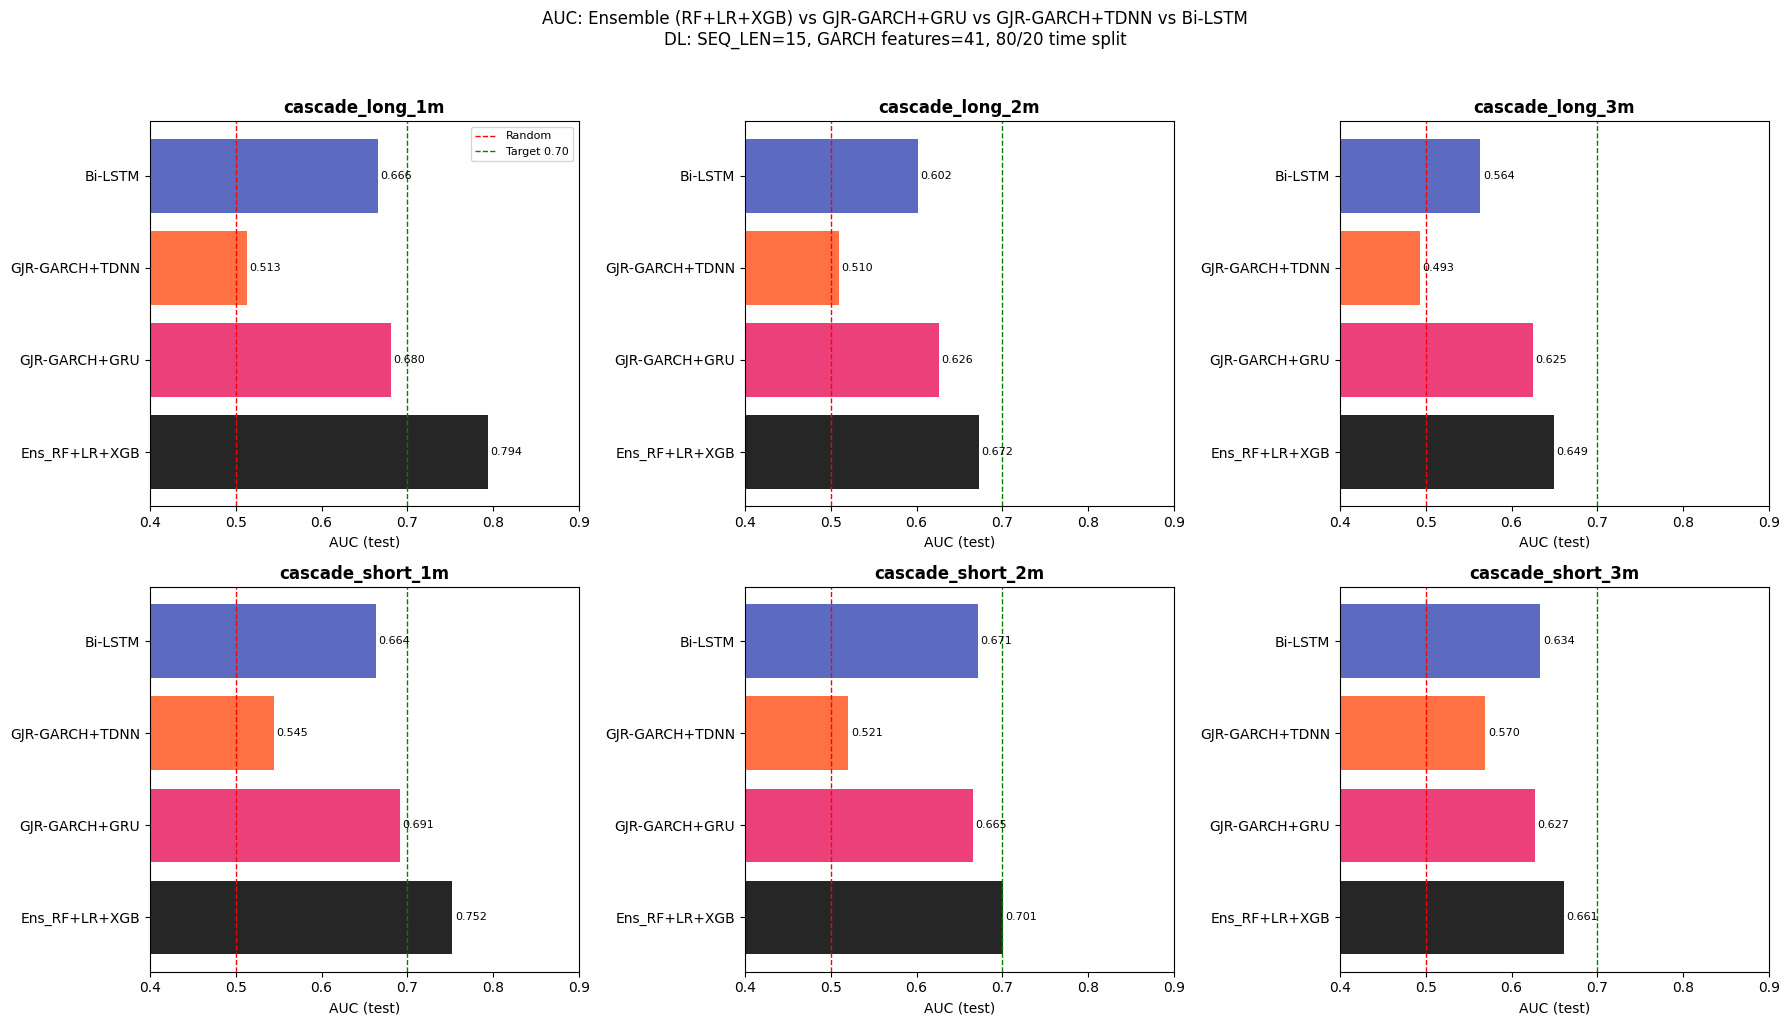

Saved → notebooks/dl_vs_ensemble_auc.png


In [22]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

dl_colors = {
    PROD_MODEL:       '#000000',
    'GJR-GARCH+GRU':  '#E91E63',
    'GJR-GARCH+TDNN': '#FF5722',
    'Bi-LSTM':        '#3F51B5',
}

for i, target in enumerate(TARGETS):
    ax   = axes[i]
    vals = [df_cmp.loc[target, c] for c in cols if df_cmp.loc[target, c] is not None]
    lbls = [c for c in cols if df_cmp.loc[target, c] is not None]
    clrs = [dl_colors.get(c, 'gray') for c in lbls]

    bars = ax.barh(lbls, vals, color=clrs, alpha=0.85)
    ax.axvline(0.50, color='red',   ls='--', lw=1, label='Random')
    ax.axvline(0.70, color='green', ls='--', lw=1, label='Target 0.70')
    for bar, v in zip(bars, vals):
        ax.text(v + 0.003, bar.get_y() + bar.get_height() / 2,
                f'{v:.3f}', va='center', fontsize=8)
    ax.set_xlim(0.40, 0.90)
    ax.set_title(target, fontweight='bold')
    ax.set_xlabel('AUC (test)')
    if i == 0:
        ax.legend(fontsize=8)

plt.suptitle(
    'AUC: Ensemble (RF+LR+XGB) vs GJR-GARCH+GRU vs GJR-GARCH+TDNN vs Bi-LSTM\n'
    f'DL: SEQ_LEN={SEQ_LEN}, GARCH features={n_feat_g}, 80/20 time split',
    fontsize=12, y=1.02,
)
plt.tight_layout()
plt.savefig('/home/coder/notebooks/dl_vs_ensemble_auc.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved → notebooks/dl_vs_ensemble_auc.png')

In [23]:
print('=' * 72)
print('KẾT LUẬN — GJR-GARCH + DL vs Production Ensemble')
print('=' * 72)

avg_prod = avg[PROD_MODEL]
for dm in DL_MODELS:
    if dm not in avg:
        continue
    d = avg[dm] - avg_prod
    sign = '▲' if d > 0 else '▼'
    print(f'\n  {dm}:  avg AUC = {avg[dm]:.4f}  ({sign}{abs(d):.4f} vs production)')

print()
print('Nhận xét:')
print('  • DL cần chuỗi 15 phút → không dùng được row đầu tiên sau khởi động')
print('  • GRU ít tham số nhất → train nhanh nhất, phù hợp retrain mỗi giờ')
print('  • TDNN (dilated conv) song song hoá tốt hơn GRU/LSTM trên CPU')
print('  • Bi-LSTM: nhiều tham số nhất, nhưng backward pass chỉ trong cửa sổ → causal OK')
print()
print('Điều kiện để upgrade production sang DL:')
print('  1. DL avg AUC > Ensemble + 0.01 sustained qua nhiều train cycles')
print('  2. Retrain time < 5 phút (hiện auto_train chạy mỗi 60 phút)')
print('  3. Cần >= 50k rows để DL không overfit (hiện ~15k rows)')

KẾT LUẬN — GJR-GARCH + DL vs Production Ensemble

  GJR-GARCH+GRU:  avg AUC = 0.6526  (▼0.0524 vs production)

  GJR-GARCH+TDNN:  avg AUC = 0.5252  (▼0.1797 vs production)

  Bi-LSTM:  avg AUC = 0.6333  (▼0.0716 vs production)

Nhận xét:
  • DL cần chuỗi 15 phút → không dùng được row đầu tiên sau khởi động
  • GRU ít tham số nhất → train nhanh nhất, phù hợp retrain mỗi giờ
  • TDNN (dilated conv) song song hoá tốt hơn GRU/LSTM trên CPU
  • Bi-LSTM: nhiều tham số nhất, nhưng backward pass chỉ trong cửa sổ → causal OK

Điều kiện để upgrade production sang DL:
  1. DL avg AUC > Ensemble + 0.01 sustained qua nhiều train cycles
  2. Retrain time < 5 phút (hiện auto_train chạy mỗi 60 phút)
  3. Cần >= 50k rows để DL không overfit (hiện ~15k rows)
